In [2]:
import os
import numpy as np
import mne


***Loading data***

In [3]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = os.path.join(sample_data_folder, 'MEG', 'sample', 'sample_audvis_filt-0-40_raw.fif')
raw = mne.io.read_raw_fif(sample_data_raw_file)
raw = raw.pick_types(meg=False, eeg=True, eog=False, exclude='bads')

Opening raw data file C:\Users\Manish\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Removing projector <Projection | PCA-v1, active : False, n_channels : 102>
Removing projector <Projection | PCA-v2, active : False, n_channels : 102>
Removing projector <Projection | PCA-v3, active : False, n_channels : 102>


In [5]:
raw.info

<Info | 14 non-empty values
 bads: []
 ch_names: EEG 001, EEG 002, EEG 003, EEG 004, EEG 005, EEG 006, EEG 007, ...
 chs: 59 EEG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 59
 projs: Average EEG reference: off
 sfreq: 150.2 Hz
>

Cropping Data:Keeps the first minute of data and discards the rest

In [6]:
raw.crop(0, 60) 

<Raw | sample_audvis_filt-0-40_raw.fif, 59 x 9010 (60.0 s), ~2.9 MB, data not loaded>

***Plotting EEG Signals***

Using matplotlib as 2D backend.


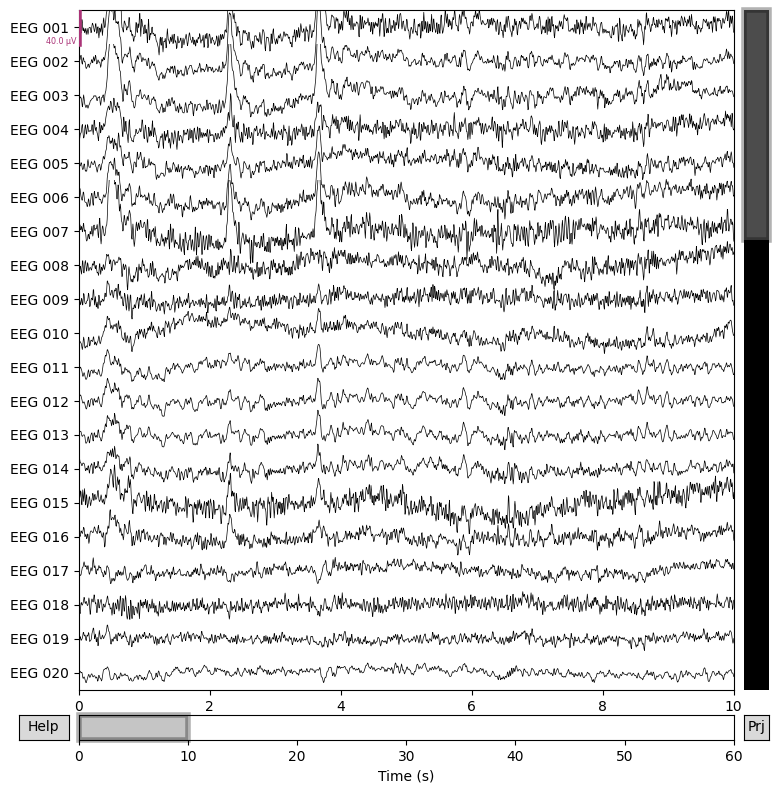

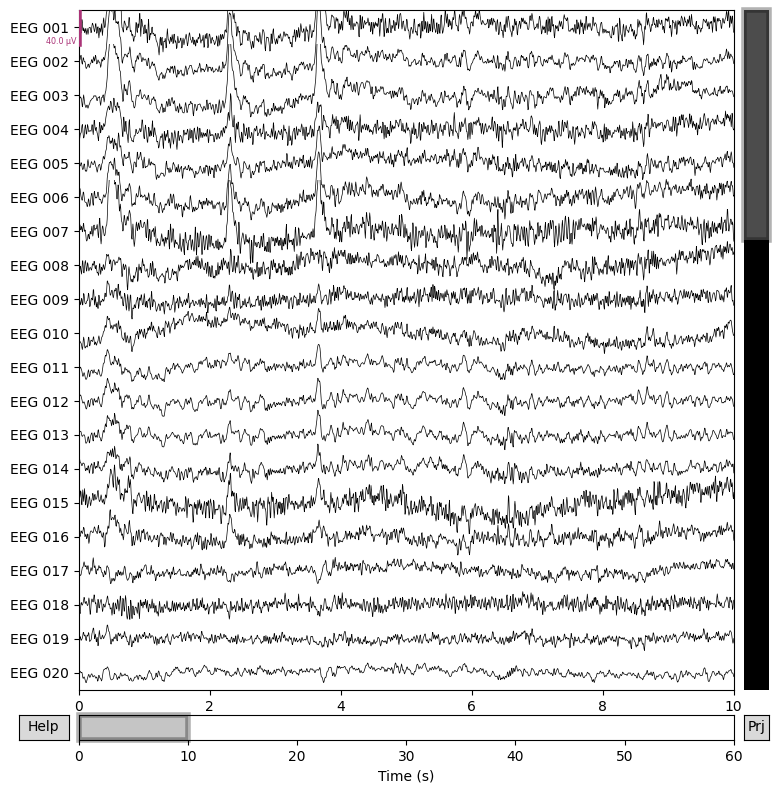

In [7]:
raw.plot()

***Preprocessing***

*Resampling*


Downsampling the EEG signal can help save a lot of computation time

In [8]:
raw.resample(600) 

<Raw | sample_audvis_filt-0-40_raw.fif, 59 x 36003 (60.0 s), ~19.1 MB, data loaded>

*Filtering*

Raw objects have a filter method that takes two arguments - lfreq represents the lower pass-band edge, and hfreq that represents the upper pass-band edge.

*High-pass filtering*: attenuates frequencies below a certain cutoff frequency. The rest of the signal remains unchanged

In [9]:
raw.filter(1., None)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1981 samples (3.302 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  59 out of  59 | elapsed:    0.0s finished


<Raw | sample_audvis_filt-0-40_raw.fif, 59 x 36003 (60.0 s), ~19.1 MB, data loaded>

*Low-pass filtering*:It is essentially the opposite of high-pass filtering. Instead of attenuating parts of the signal below a certain frequency, it attenuates parts of the signal above a certain frequency. 

In [10]:
raw.filter(None, 50.)


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 159 samples (0.265 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  59 out of  59 | elapsed:    0.1s finished


<Raw | sample_audvis_filt-0-40_raw.fif, 59 x 36003 (60.0 s), ~19.1 MB, data loaded>

***Epoching***

Reading events

In [11]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = os.path.join(sample_data_folder, 'MEG', 'sample', 'sample_audvis_raw.fif')
raw = mne.io.read_raw_fif(sample_data_raw_file, verbose=False)


In [12]:
events = mne.find_events(raw)


320 events found
Event IDs: [ 1  2  3  4  5 32]


Creating equal-length events

In [13]:
events = mne.make_fixed_length_events(raw, start=0, stop=10, duration=1.)


In [14]:
events = mne.make_fixed_length_events(raw, start=0, stop=10, duration=1., overlap=0.5)


Creating Epoched Data from Events

In [15]:
epochs = mne.Epochs(raw, events, preload=True).pick_types(eeg=True)


Not setting metadata
19 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] sec
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Loading data for 19 events and 421 original time points ...
1 bad epochs dropped
Removing projector <Projection | PCA-v1, active : True, n_channels : 102>
Removing projector <Projection | PCA-v2, active : True, n_channels : 102>
Removing projector <Projection | PCA-v3, active : True, n_channels : 102>


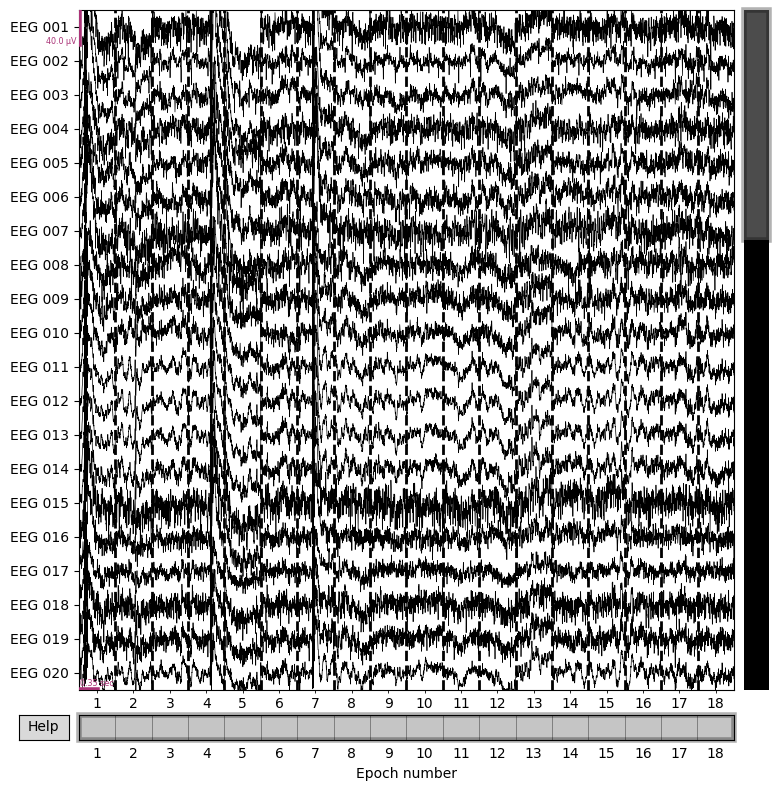

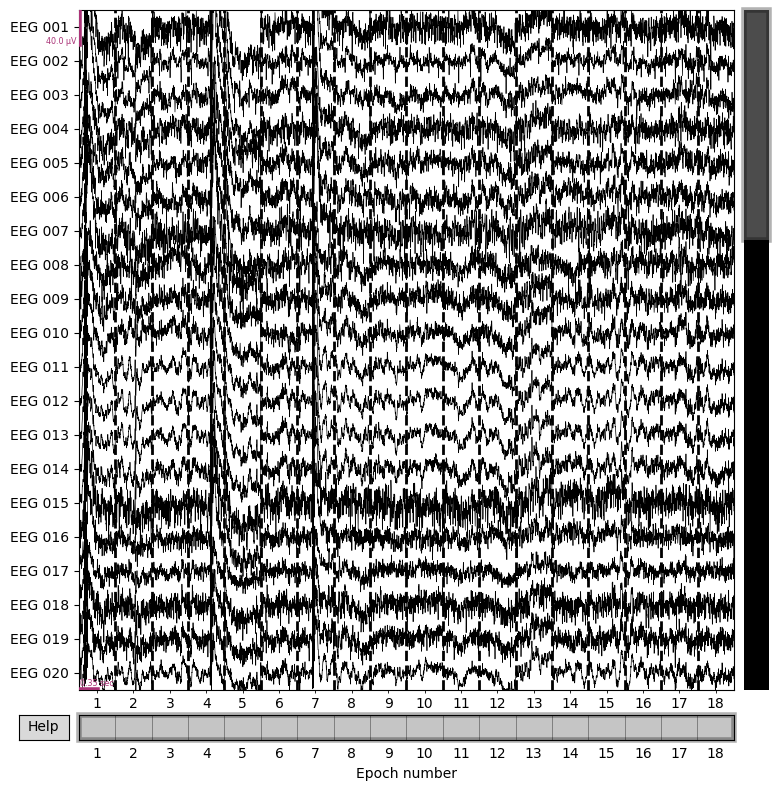

In [19]:
epochs['1'].plot()
